In [1]:
# ============================================================
# Cell 1 : Import Libraries
# ============================================================

import os
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

warnings.filterwarnings("ignore")

print("=" * 60)
print("PyTorch Version :", torch.__version__)
print("Torchvision     :", torchvision.__version__)
print("CUDA Available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

print("=" * 60)

PyTorch Version : 2.10.0+cu128
Torchvision     : 0.25.0+cu128
CUDA Available  : True
GPU             : Tesla T4


In [2]:
# ============================================================
# Cell 2 : Configuration & Dataset Paths
# ============================================================

# -----------------------
# Random Seed
# -----------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# -----------------------
# Device
# -----------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------
# Image Settings
# -----------------------
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

# -----------------------
# Training Settings
# -----------------------
EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

# -----------------------
# Number of Classes
# -----------------------
NUM_CLASSES = 14

CLASS_NAMES = [
    "Atelectasis",
    "Cardiomegaly",
    "Effusion",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pneumonia",
    "Pneumothorax",
    "Consolidation",
    "Edema",
    "Emphysema",
    "Fibrosis",
    "Pleural_Thickening",
    "Hernia"
]

# ============================================================
# Kaggle Dataset Paths
# ============================================================

# Change this ONLY if your dataset folder has a different name
DATASET_ROOT = "/kaggle/input"

print("=" * 60)
print("Available datasets inside /kaggle/input:")
print("=" * 60)

for folder in sorted(os.listdir(DATASET_ROOT)):
    print(folder)

print("=" * 60)

Available datasets inside /kaggle/input:
datasets


In [3]:
# ============================================================
# Cell 3 : Automatically Locate NIH ChestX-ray14 Dataset
# ============================================================

from pathlib import Path
import os

DATASET_ROOT = Path("/kaggle/input")

print("=" * 70)
print("Searching for NIH ChestX-ray14 dataset...")
print("=" * 70)

# ------------------------------------------------------------
# Find metadata CSV
# ------------------------------------------------------------
csv_candidates = list(DATASET_ROOT.rglob("Data_Entry_2017.csv"))

if len(csv_candidates) == 0:
    raise FileNotFoundError("❌ Data_Entry_2017.csv not found!")

METADATA_PATH = csv_candidates[0]

# ------------------------------------------------------------
# Find all PNG images
# ------------------------------------------------------------
IMAGE_FILES = list(DATASET_ROOT.rglob("*.png"))

if len(IMAGE_FILES) == 0:
    raise FileNotFoundError("❌ No PNG images found!")

# ------------------------------------------------------------
# Image lookup dictionary
# ------------------------------------------------------------
IMAGE_PATH_DICT = {
    img.name: str(img)
    for img in IMAGE_FILES
}

print(f"Metadata File : {METADATA_PATH}")
print(f"Total Images  : {len(IMAGE_FILES):,}")

print("\nExample Image Paths:")
for i in range(min(5, len(IMAGE_FILES))):
    print(IMAGE_FILES[i])

print("=" * 70)
print("Dataset successfully located.")
print("=" * 70)

Searching for NIH ChestX-ray14 dataset...
Metadata File : /kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv
Total Images  : 112,120

Example Image Paths:
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00006199_010.png
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00004833_016.png
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00006260_000.png
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00004911_010.png
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00004186_007.png
Dataset successfully located.


In [4]:
# ============================================================
# Cell 4 : Load Metadata
# ============================================================

metadata = pd.read_csv(METADATA_PATH)

print("=" * 70)
print("Metadata Shape")
print(metadata.shape)

print("\nColumns")
print(metadata.columns.tolist())

print("\nFirst Five Rows")
display(metadata.head())

print("\nMissing Values")
display(metadata.isnull().sum())

print("=" * 70)

Metadata Shape
(112120, 12)

Columns
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']

First Five Rows


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN



Missing Values


Image Index                         0
Finding Labels                      0
Follow-up #                         0
Patient ID                          0
Patient Age                         0
Patient Gender                      0
View Position                       0
OriginalImage[Width                 0
Height]                             0
OriginalImagePixelSpacing[x         0
y]                                  0
Unnamed: 11                    112120
dtype: int64

In [5]:
# ============================================================
# Cell 5 : Clean Metadata & Multi-Label Encoding
# ============================================================

# Drop unnecessary column if present
metadata = metadata.drop(columns=["Unnamed: 11"], errors="ignore")

# ------------------------------------------------------------
# 14 NIH Disease Classes
# ------------------------------------------------------------

DISEASES = sorted([
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Effusion",
    "Emphysema",
    "Fibrosis",
    "Hernia",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pleural_Thickening",
    "Pneumonia",
    "Pneumothorax"
])

print("Disease Classes:")
print(DISEASES)

# ------------------------------------------------------------
# Multi-hot encoding
# ------------------------------------------------------------

for disease in DISEASES:
    metadata[disease] = metadata["Finding Labels"].apply(
        lambda x: int(disease in x.split("|"))
    )

# Add image path
metadata["Image Path"] = metadata["Image Index"].map(IMAGE_PATH_DICT)

# Remove images whose paths were not found
metadata = metadata.dropna(subset=["Image Path"]).reset_index(drop=True)

print("\nMetadata Shape :", metadata.shape)

display(metadata.head())

Disease Classes:
['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

Metadata Shape : (112120, 26)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,Image Path
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,...,0,0,0,0,0,0,0,0,0,/kaggle/input/datasets/organizations/nih-chest...
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,...,1,0,0,0,0,0,0,0,0,/kaggle/input/datasets/organizations/nih-chest...
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,...,0,0,0,0,0,0,0,0,0,/kaggle/input/datasets/organizations/nih-chest...
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,0,0,/kaggle/input/datasets/organizations/nih-chest...
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,...,0,0,1,0,0,0,0,0,0,/kaggle/input/datasets/organizations/nih-chest...


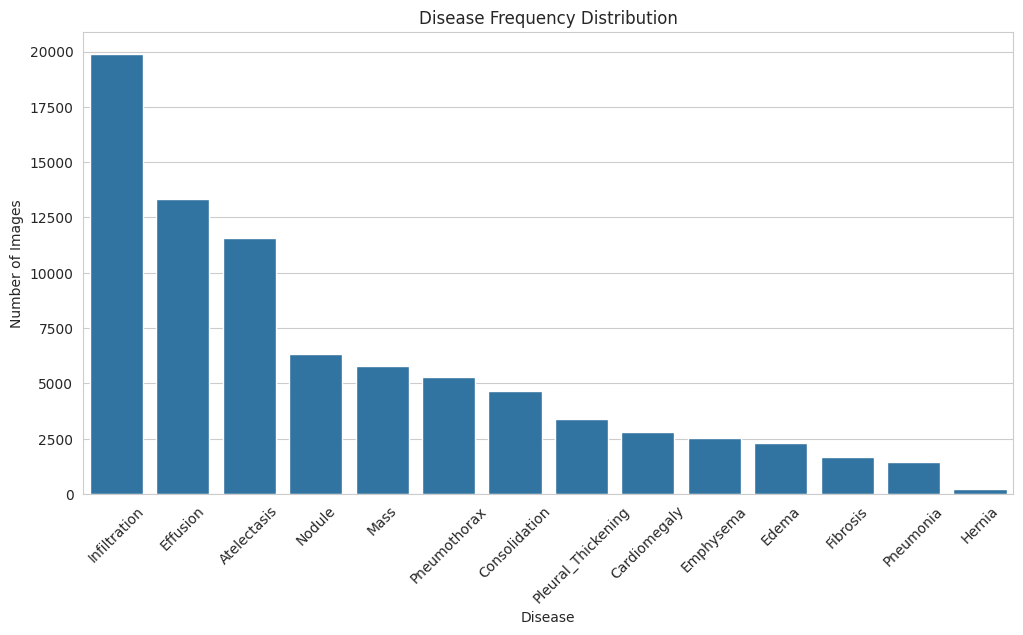

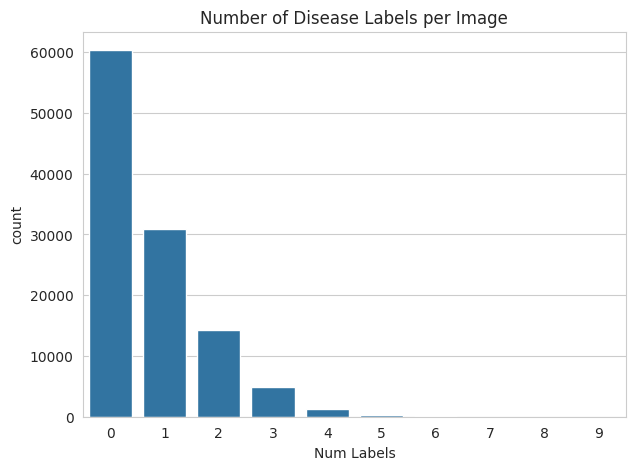

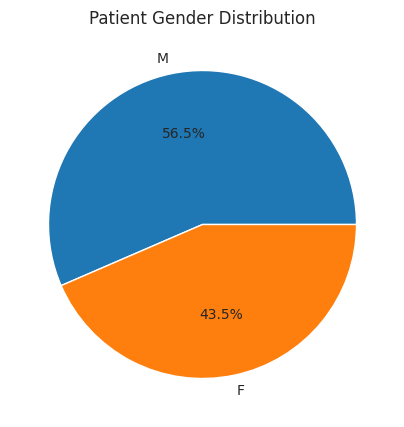

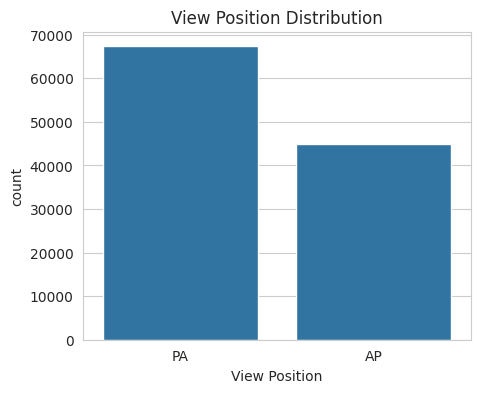

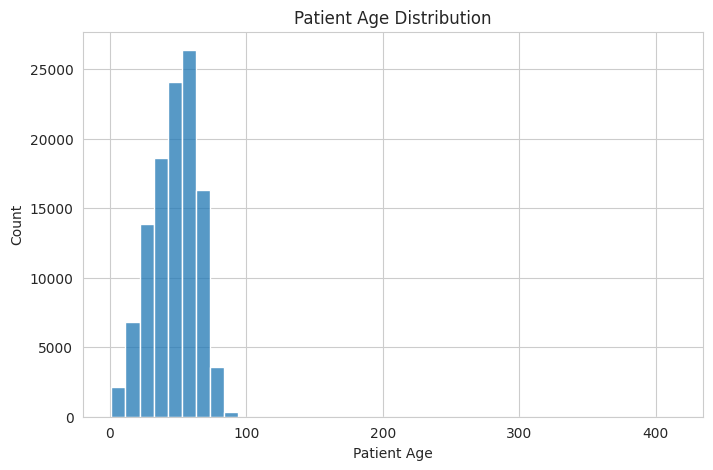

In [6]:
# ============================================================
# Cell 6 : Exploratory Data Analysis
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ------------------------------------------------------------
# Disease Frequency
# ------------------------------------------------------------

disease_counts = metadata[DISEASES].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=disease_counts.index,
    y=disease_counts.values,
)

plt.xticks(rotation=45)
plt.title("Disease Frequency Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Images")

plt.show()

# ------------------------------------------------------------
# Labels per Image
# ------------------------------------------------------------

metadata["Num Labels"] = metadata[DISEASES].sum(axis=1)

plt.figure(figsize=(7,5))

sns.countplot(
    x=metadata["Num Labels"]
)

plt.title("Number of Disease Labels per Image")

plt.show()

# ------------------------------------------------------------
# Gender Distribution
# ------------------------------------------------------------

plt.figure(figsize=(5,5))

metadata["Patient Gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Patient Gender Distribution")

plt.show()

# ------------------------------------------------------------
# View Position
# ------------------------------------------------------------

plt.figure(figsize=(5,4))

sns.countplot(
    x=metadata["View Position"]
)

plt.title("View Position Distribution")

plt.show()

# ------------------------------------------------------------
# Age Distribution
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(
    metadata["Patient Age"],
    bins=40
)

plt.title("Patient Age Distribution")

plt.show()

In [7]:
# ============================================================
# Cell 7 : Patient-wise Train/Val/Test Split
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

# ------------------------------------------------------------
# First Split
# 70% Train
# 30% Remaining
# ------------------------------------------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=SEED
)

train_idx, temp_idx = next(
    gss.split(
        metadata,
        groups=metadata["Patient ID"]
    )
)

train_df = metadata.iloc[train_idx].reset_index(drop=True)
temp_df = metadata.iloc[temp_idx].reset_index(drop=True)

# ------------------------------------------------------------
# Second Split
# Remaining 30%
#
# Validation = 20%
# Test = 10%
#
# => split remaining in ratio 2:1
# ------------------------------------------------------------

gss2 = GroupShuffleSplit(
    n_splits=1,
    train_size=2/3,
    random_state=SEED
)

val_idx, test_idx = next(
    gss2.split(
        temp_df,
        groups=temp_df["Patient ID"]
    )
)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print("="*60)
print("Train :", len(train_df))
print("Validation :", len(val_df))
print("Test :", len(test_df))
print("="*60)

Train : 78566
Validation : 22204
Test : 11350


In [8]:
# ============================================================
# Cell 9 : CLAHE Image Enhancement
# ============================================================

import cv2
import numpy as np

def apply_clahe(image):
    """
    Apply CLAHE to grayscale chest X-ray.
    Input  : numpy array (uint8)
    Output : numpy array (uint8)
    """

    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    image = clahe.apply(image)

    return image

In [9]:
# ============================================================
# Cell 10 : Image Transformations
# ============================================================

from torchvision import transforms

imagenet_mean = [0.485]
imagenet_std = [0.229]

train_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(7),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.03,0.03),
        scale=(0.95,1.05)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )

])

val_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )

])

In [10]:
class NIHChestDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # -------------------------
        # Load grayscale image
        # -------------------------
        image = cv2.imread(
            row["Image Path"],
            cv2.IMREAD_GRAYSCALE
        )

        image = apply_clahe(image)

        # -------------------------------------------------
        # Convert 1 channel → 3 channels
        # -------------------------------------------------
        image = cv2.cvtColor(
            image,
            cv2.COLOR_GRAY2RGB
        )

        label = row[DISEASES].values.astype(np.float32)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label)

In [11]:
# ============================================================
# Cell 12 : Build Dataset Objects
# ============================================================

train_dataset = NIHChestDataset(
    train_df,
    transform=train_transform
)

val_dataset = NIHChestDataset(
    val_df,
    transform=val_transform
)

test_dataset = NIHChestDataset(
    test_df,
    transform=val_transform
)

print("Train :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test :", len(test_dataset))

Train : 78566
Validation : 22204
Test : 11350


In [12]:
# ============================================================
# Cell 13 : DataLoaders
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True

)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True

)

print("Train batches :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches : 2456
Validation batches : 694
Test batches : 355


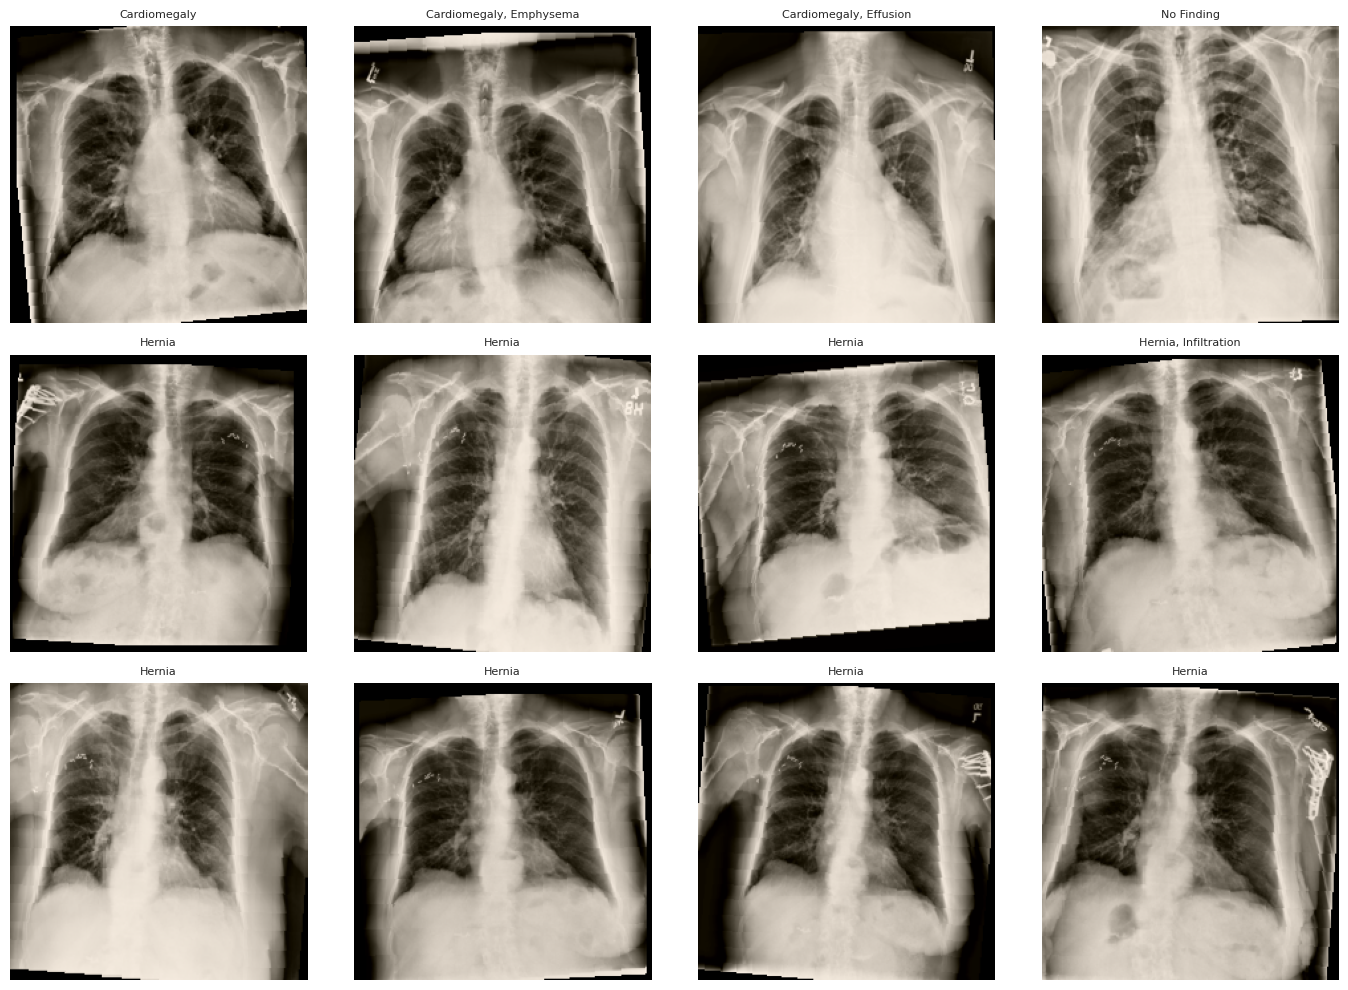

In [13]:
# ============================================================
# Cell 14 : Visualize Preprocessed Images
# ============================================================

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i in range(12):

    image, label = train_dataset[i]

    # Tensor -> NumPy
    image = image.numpy()

    # CHW -> HWC
    image = np.transpose(image, (1, 2, 0))

    # De-normalize
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    axes[i].imshow(image)

    disease_names = [
        DISEASES[j]
        for j in range(len(DISEASES))
        if label[j] == 1
    ]

    if len(disease_names) == 0:
        disease_names = ["No Finding"]

    axes[i].set_title(
        ", ".join(disease_names[:2]),
        fontsize=8
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()

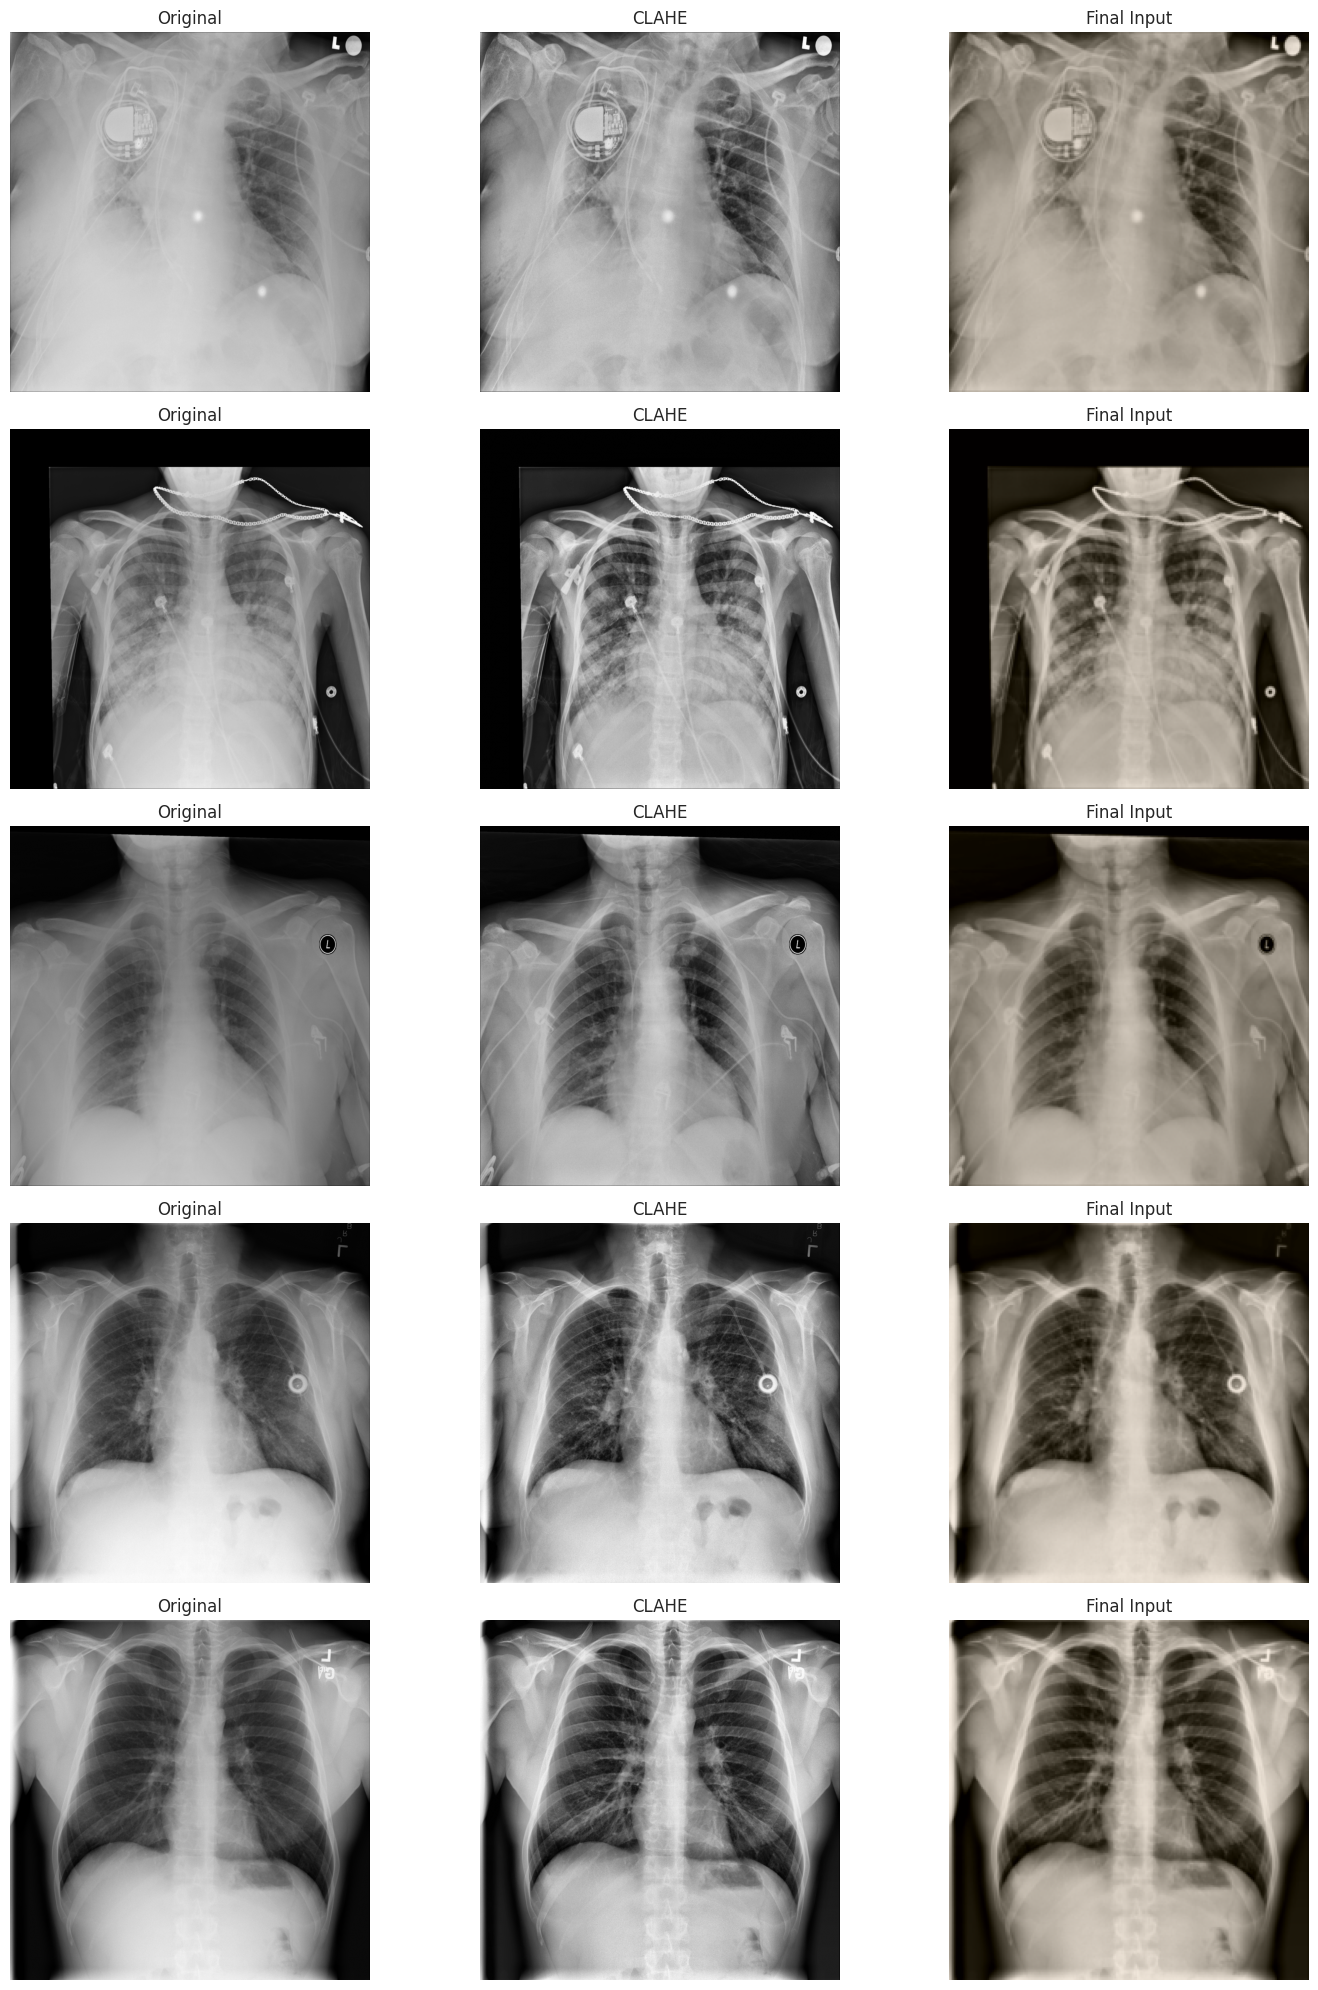

In [14]:
# ============================================================
# Cell 15 : Visualize Preprocessing Pipeline
# ============================================================

import random

fig, axes = plt.subplots(5, 3, figsize=(15, 20))

sample_indices = random.sample(range(len(train_df)), 5)

for row_idx, idx in enumerate(sample_indices):

    row = train_df.iloc[idx]

    # ---------------------------------------------------
    # Original Image
    # ---------------------------------------------------

    original = cv2.imread(
        row["Image Path"],
        cv2.IMREAD_GRAYSCALE
    )

    # ---------------------------------------------------
    # CLAHE
    # ---------------------------------------------------

    clahe = apply_clahe(original)

    # ---------------------------------------------------
    # RGB Conversion
    # ---------------------------------------------------

    rgb = cv2.cvtColor(
        clahe,
        cv2.COLOR_GRAY2RGB
    )

    # ---------------------------------------------------
    # Transform
    # ---------------------------------------------------

    transformed = val_transform(rgb)

    image = transformed.numpy()
    image = np.transpose(image, (1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    # ---------------------------------------------------
    # Plot
    # ---------------------------------------------------

    axes[row_idx,0].imshow(original,cmap="gray")
    axes[row_idx,0].set_title("Original")
    axes[row_idx,0].axis("off")

    axes[row_idx,1].imshow(clahe,cmap="gray")
    axes[row_idx,1].set_title("CLAHE")
    axes[row_idx,1].axis("off")

    axes[row_idx,2].imshow(image)
    axes[row_idx,2].set_title("Final Input")
    axes[row_idx,2].axis("off")

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# Cell 16 : Compute Positive Class Weights
# ============================================================

positive_counts = train_df[DISEASES].sum().values

negative_counts = len(train_df) - positive_counts

pos_weight = torch.tensor(
    negative_counts / positive_counts,
    dtype=torch.float32
).to(DEVICE)

weights_df = pd.DataFrame({
    "Disease": DISEASES,
    "Positive Samples": positive_counts,
    "Negative Samples": negative_counts,
    "Positive Weight": pos_weight.cpu().numpy()
})

display(weights_df)

,Disease,Positive Samples,Negative Samples,Positive Weight
0,Atelectasis,8190,70376,8.592918
1,Cardiomegaly,1891,76675,40.547329
2,Consolidation,3228,75338,23.338909
3,Edema,1630,76936,47.200001
4,Effusion,9438,69128,7.324433
5,Emphysema,1666,76900,46.158463
6,Fibrosis,1156,77410,66.963669
7,Hernia,158,78408,496.253174
8,Infiltration,13868,64698,4.665273
9,Mass,4260,74306,17.442722


In [16]:
# ============================================================
# Cell 17 : ConvNeXt Tiny
# ============================================================

from torchvision.models import (
    convnext_tiny,
    ConvNeXt_Tiny_Weights
)

weights = ConvNeXt_Tiny_Weights.DEFAULT

model = convnext_tiny(
    weights=weights
)

print(model)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 187MB/s]


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [17]:
# ============================================================
# Cell 18 : Replace Classification Head
# ============================================================

in_features = model.classifier[2].in_features

model.classifier[2] = nn.Linear(
    in_features,
    NUM_CLASSES
)

model = model.to(DEVICE)

print(model.classifier)

Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=14, bias=True)
)


In [18]:
# ============================================================
# Cell 19 : BCE Loss
# ============================================================

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

print(criterion)

BCEWithLogitsLoss()


In [19]:
# ============================================================
# Cell 20 : Optimizer
# ============================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=1e-4

)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=20

)

print("Optimizer Ready")

Optimizer Ready


In [20]:
# ============================================================
# Cell 21 : AMP
# ============================================================

from torch.cuda.amp import (
    autocast,
    GradScaler
)

scaler = GradScaler()

print("AMP Enabled")

AMP Enabled


In [21]:
# ============================================================
# Cell 22 : Model Summary
# ============================================================

total = sum(
    p.numel()
    for p in model.parameters()
)

trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("="*60)
print(f"Total Parameters : {total:,}")
print(f"Trainable Params : {trainable:,}")
print("="*60)

Total Parameters : 27,830,894
Trainable Params : 27,830,894


In [22]:
# ============================================================
# Cell 23 : Metrics
# ============================================================

from sklearn.metrics import (

    roc_auc_score,

    f1_score,

    precision_score,

    recall_score

)

In [23]:
# ============================================================
# Cell 24 : Train One Epoch
# ============================================================

from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):

    model.train()

    running_loss = 0

    targets_all = []
    probs_all = []

    pbar = tqdm(loader)

    for images, labels in pbar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda"):

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        probs = torch.sigmoid(outputs)

        targets_all.append(labels.detach().cpu())
        probs_all.append(probs.detach().cpu())

        pbar.set_description(
            f"Loss {loss.item():.4f}"
        )

    targets_all = torch.cat(targets_all).numpy()
    probs_all = torch.cat(probs_all).numpy()

    preds = (probs_all > 0.5).astype(int)

    metrics = {

        "loss": running_loss / len(loader),

        "f1": f1_score(
            targets_all,
            preds,
            average="macro",
            zero_division=0
        ),

        "precision": precision_score(
            targets_all,
            preds,
            average="macro",
            zero_division=0
        ),

        "recall": recall_score(
            targets_all,
            preds,
            average="macro",
            zero_division=0
        )

    }

    try:

        metrics["auroc"] = roc_auc_score(
            targets_all,
            probs_all,
            average="macro"
        )

    except:

        metrics["auroc"] = 0

    return metrics

In [24]:
# ============================================================
# Cell 25 : Validation
# ============================================================

@torch.no_grad()

def validate_one_epoch(model, loader, criterion, device):

    model.eval()

    running_loss = 0

    targets_all = []
    probs_all = []

    pbar = tqdm(loader)

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        running_loss += loss.item()

        probs = torch.sigmoid(outputs)

        targets_all.append(labels.cpu())
        probs_all.append(probs.cpu())

    targets_all = torch.cat(targets_all).numpy()
    probs_all = torch.cat(probs_all).numpy()

    preds = (probs_all > 0.5).astype(int)

    metrics = {

        "loss": running_loss / len(loader),

        "f1": f1_score(
            targets_all,
            preds,
            average="macro",
            zero_division=0
        ),

        "precision": precision_score(
            targets_all,
            preds,
            average="macro",
            zero_division=0
        ),

        "recall": recall_score(
            targets_all,
            preds,
            average="macro",
            zero_division=0
        )

    }

    try:

        metrics["auroc"] = roc_auc_score(
            targets_all,
            probs_all,
            average="macro"
        )

    except:

        metrics["auroc"] = 0

    return metrics

In [25]:
# ============================================================
# Cell 26 : History
# ============================================================

history = {

    "train_loss": [],
    "val_loss": [],

    "train_auc": [],
    "val_auc": [],

    "train_f1": [],
    "val_f1": [],

    "train_precision": [],
    "val_precision": [],

    "train_recall": [],
    "val_recall": []

}

best_auc = 0

patience = 5

counter = 0

In [26]:
# ============================================================
# Cell 27 : Main Training Loop
# ============================================================

import os
import time

SAVE_PATH = "/kaggle/working/best_convnext_baseline.pth"

best_auc = 0.0
counter = 0

start_time = time.time()

print("=" * 80)
print("🚀 Starting Training...")
print("=" * 80)

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print("-" * 80)

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        scaler=scaler,
        device=DEVICE
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_metrics = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE
    )

    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler.step()

    # --------------------------------------------------------
    # Store History
    # --------------------------------------------------------

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])

    history["train_auc"].append(train_metrics["auroc"])
    history["val_auc"].append(val_metrics["auroc"])

    history["train_f1"].append(train_metrics["f1"])
    history["val_f1"].append(val_metrics["f1"])

    history["train_precision"].append(train_metrics["precision"])
    history["val_precision"].append(val_metrics["precision"])

    history["train_recall"].append(train_metrics["recall"])
    history["val_recall"].append(val_metrics["recall"])

    # --------------------------------------------------------
    # Print Results
    # --------------------------------------------------------

    print(f"Train Loss      : {train_metrics['loss']:.4f}")
    print(f"Validation Loss : {val_metrics['loss']:.4f}")

    print(f"Train AUROC     : {train_metrics['auroc']:.4f}")
    print(f"Validation AUROC: {val_metrics['auroc']:.4f}")

    print(f"Train F1        : {train_metrics['f1']:.4f}")
    print(f"Validation F1   : {val_metrics['f1']:.4f}")

    print(f"Train Precision : {train_metrics['precision']:.4f}")
    print(f"Validation Prec.: {val_metrics['precision']:.4f}")

    print(f"Train Recall    : {train_metrics['recall']:.4f}")
    print(f"Validation Rec. : {val_metrics['recall']:.4f}")

    # --------------------------------------------------------
    # Save Best Model
    # --------------------------------------------------------

    if val_metrics["auroc"] > best_auc:

        best_auc = val_metrics["auroc"]
        counter = 0

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_auc": best_auc,
            "history": history,
        }

        torch.save(checkpoint, SAVE_PATH)

        print("✅ Best model saved.")

    else:

        counter += 1
        print(f"No improvement ({counter}/{patience})")

    # --------------------------------------------------------
    # Early Stopping
    # --------------------------------------------------------

    if counter >= patience:

        print("\n🛑 Early stopping triggered.")
        break

elapsed = (time.time() - start_time) / 60

print("\n" + "=" * 80)
print("🎉 Training Complete")
print(f"Best Validation AUROC : {best_auc:.4f}")
print(f"Training Time         : {elapsed:.2f} minutes")
print(f"Best Model Saved At   : {SAVE_PATH}")
print("=" * 80)

🚀 Starting Training...

Epoch [1/20]
--------------------------------------------------------------------------------


  0%|          | 0/2456 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


  0%|          | 0/694 [00:00<?, ?it/s]

Train Loss      : 1.1573
Validation Loss : 1.0167
Train AUROC     : 0.7540
Validation AUROC: 0.8081
Train F1        : 0.1700
Validation F1   : 0.1936
Train Precision : 0.1054
Validation Prec.: 0.1214
Train Recall    : 0.6245
Validation Rec. : 0.7060
✅ Best model saved.

Epoch [2/20]
--------------------------------------------------------------------------------


...

Train Loss      : 0.5586
Validation Loss : 1.6814
Train AUROC     : 0.9290
Validation AUROC: 0.8163
Train F1        : 0.3970
Validation F1   : 0.2846
Train Precision : 0.2653
Validation Prec.: 0.2064
Train Recall    : 0.8577
Validation Rec. : 0.5617
No improvement (4/5)

Epoch [11/20]
--------------------------------------------------------------------------------


  0%|          | 0/2456 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


  0%|          | 0/694 [00:00<?, ?it/s]

Train Loss      : 0.4735
Validation Loss : 1.8431
Train AUROC     : 0.9430
Validation AUROC: 0.8142
Train F1        : 0.4507
Validation F1   : 0.2918
Train Precision : 0.3083
Validation Prec.: 0.2049
Train Recall    : 0.8875
Validation Rec. : 0.5336
No improvement (5/5)

🛑 Early stopping triggered.

🎉 Training Complete
Best Validation AUROC : 0.8371
Training Time         : 339.05 minutes
Best Model Saved At   : /kaggle/working/best_convnext_baseline.pth


In [27]:
# ============================================================
# Cell 28 : Load Best Model
# ============================================================

checkpoint = torch.load(
    "/kaggle/working/best_convnext_baseline.pth",
    map_location=DEVICE
)

model.load_state_dict(checkpoint["model"])

model.eval()

print("="*60)
print("Best Model Loaded")
print("Best AUROC :", checkpoint["best_auc"])
print("="*60)

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 

In [ ]:
# ============================================================
# Cell 29 : Test Inference
# ============================================================

from tqdm.auto import tqdm

model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(DEVICE)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float()

        all_labels.append(labels.numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

all_labels = np.concatenate(all_labels)
all_probs = np.concatenate(all_probs)
all_preds = np.concatenate(all_preds)

print("Inference Complete.")
print(all_labels.shape)
print(all_preds.shape)

In [ ]:
# ============================================================
# Cell 30 : Classification Report
# ============================================================

from sklearn.metrics import classification_report

report = classification_report(

    all_labels,

    all_preds,

    target_names=DISEASES,

    zero_division=0,

    output_dict=True

)

report_df = pd.DataFrame(report).transpose()

display(report_df)

report_df.to_csv(
    "/kaggle/working/classification_report.csv",
    index=True
)

In [ ]:
# ============================================================
# Cell 31 : Confusion Matrices
# ============================================================

from sklearn.metrics import multilabel_confusion_matrix

cms = multilabel_confusion_matrix(
    all_labels,
    all_preds
)

fig, axes = plt.subplots(4,4,figsize=(18,18))

axes = axes.flatten()

for i, cm in enumerate(cms):

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[i]
    )

    axes[i].set_title(DISEASES[i])

for j in range(len(DISEASES),16):
    axes[j].axis("off")

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# Cell 32 : Training Curves
# ============================================================

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, history["train_loss"], label="Train")
plt.plot(epochs, history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()

plt.show()

In [ ]:
# ============================================================
# Cell 33 : AUROC Curve
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history["train_auc"],
    label="Train AUROC"
)

plt.plot(
    epochs,
    history["val_auc"],
    label="Validation AUROC"
)

plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.title("Training AUROC")

plt.legend()

plt.show()

In [ ]:
# ============================================================
# Cell 34 : F1 Curve
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    history["train_f1"],
    label="Train"
)

plt.plot(
    epochs,
    history["val_f1"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")

plt.title("F1 Score")

plt.legend()

plt.show()

In [ ]:
# ============================================================
# Cell 35 : ROC Curves
# ============================================================

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10,8))

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(
        all_labels[:,i],
        all_probs[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{DISEASES[i]} ({roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")

plt.legend(fontsize=8)

plt.show()

In [ ]:
# ============================================================
# Cell 36 : Per-Class AUROC
# ============================================================

aurocs = []

for i in range(NUM_CLASSES):

    try:

        score = roc_auc_score(

            all_labels[:,i],

            all_probs[:,i]

        )

    except:

        score = np.nan

    aurocs.append(score)

auroc_df = pd.DataFrame({

    "Disease":DISEASES,

    "AUROC":aurocs

})

display(auroc_df)

plt.figure(figsize=(12,5))

sns.barplot(

    data=auroc_df,

    x="Disease",

    y="AUROC"

)

plt.xticks(rotation=45)

plt.show()

In [ ]:
# ============================================================
# Cell 37 : Save Results
# ============================================================

torch.save(

    model.state_dict(),

    "/kaggle/working/final_convnext_baseline.pth"

)

pd.DataFrame(history).to_csv(

    "/kaggle/working/training_history.csv",

    index=False

)

np.save(

    "/kaggle/working/test_predictions.npy",

    all_preds

)

np.save(

    "/kaggle/working/test_probabilities.npy",

    all_probs

)

print("="*60)
print("Everything Saved Successfully")
print("="*60)